## 🏦 A Predictive Model for Hotel Booking Status and Cancellations Risk (Supervised Machine Learning): Driving Revenue Optimization and Operational Efficiency

*A Case Study of Hotel Haven*


## Problem Statement
*Hotel Haven struggles with high booking cancellation rate, leading to loss of revenue and inefficient cancellation rate. However, they lack insight into reason for customer behaviour. The hotel mananagement seeks system that predict cancellations from booking data to improve operational efficiency and customer retention*


## Specific Objectives
- *Clean and prepare the hotel booking dataset for analysis and modeling*
- *Explore booking data to understand patterns, trends, and cancellation behavior*
- *Perform comprehensive analysis to identify key factors influencing booking cancellations*
- *Engineer meaningful features that improve the predictive power of the dataset*
- *Develop a machine learning model to predict booking status accurately*
- *Evaluate model performance using appropriate metrics for classification*
- *Fine-tune the model to improve accuracy, reliability, and generalization*
- *Generate actionable insights that support better customer retention and reduce cancellations*


## Workflow Overview
```
Raw Data → Cleaning and Preprocessing → Statistical Analysis → Exploratory Data Analysis → Visualizations  → Modelling → Actionable Recommendations
```

#### Import Relevant Libraries

In [645]:
# Numerical Operations
import numpy as np

# Data Cleaning, Manipulation and Visualization
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plot style
sns.set_style(None)

#Display DataFrames and visual objects
from IPython.display import display

#Setting
import warnings
warnings.filterwarnings('ignore')

#### Load Dataset

In [646]:
data = pd.read_csv(r"C:\Users\USER\Downloads\booking.csv")

In [647]:
# Inspection of Data
data.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [648]:
# Data dimension check and structural summary

print(f'Dataset shape: {data.shape[0]} rows x {data.shape[1]} columns')
data.info()

Dataset shape: 36285 rows x 17 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price         

In [649]:
# Descriptive Statistics (Statistical Summary)

data.describe().round(2)

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests
count,36285.00,36285.00,36285.00,36285.00,36285.00,36285.00,36285.00,36285.00,36285.00,36285.00,36285.00
mean,1.84,0.11,0.81,2.20,0.03,85.24,0.03,0.02,0.15,103.42,0.62
std,0.52,0.40,0.87,1.41,0.17,85.94,0.16,0.37,1.75,35.09,0.79
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2.00,0.00,0.00,1.00,0.00,17.00,0.00,0.00,0.00,80.30,0.00
50%,2.00,0.00,1.00,2.00,0.00,57.00,0.00,0.00,0.00,99.45,0.00
75%,2.00,0.00,2.00,3.00,0.00,126.00,0.00,0.00,0.00,120.00,1.00
max,4.00,10.00,7.00,17.00,1.00,443.00,1.00,13.00,58.00,540.00,5.00


### Data Cleaning and Preprocessing

#### a. Investigate and Handle Missing Data

In [650]:
missing = data.isnull().sum()
print('Missing values:')
print (missing)
print()

if missing.sum()==0:
    print('Good news! No missing values')
else:
    print('We have missing values that requires handling')

Missing values:
Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64

Good news! No missing values


#### b. Investigate and Handle Duplicates

In [651]:
duplicates = data.duplicated().sum()
print('Number of duplicates:')
print(duplicates)
print()

if duplicates.sum()==0:
    print('This is no duplicate entry in the dataset')
else:
    print('We have duplicates to handle')

Number of duplicates:
0

This is no duplicate entry in the dataset


#### c. Correct Dtypes

In [652]:
data[['car parking space', 'repeated']] = data[['car parking space', 'repeated']].astype(bool)

In [653]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  bool   
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  bool   
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

#### d. Handle Inconsistencies and Whitespace errors

In [654]:
# I. Investigate for inconsistencies and whitespace errors

for col in data.columns:
    if col not in ['number of adults', 'number of children', 'number of weekend nights', 'number of week nights', 'car parking space', 'lead time',
                   'repeated', 'average price', 'special requests', 'date of reservation']:
        print('\n', col)
        print(data[col].unique())

print()
print('No inconsistencies nor whitespace error found in entries')


 Booking_ID
['INN00001' 'INN00002' 'INN00003' ... 'INN36284' 'INN36285' 'INN36286']

 type of meal
['Meal Plan 1' 'Not Selected' 'Meal Plan 2' 'Meal Plan 3']

 room type
['Room_Type 1' 'Room_Type 4' 'Room_Type 2' 'Room_Type 6' 'Room_Type 5'
 'Room_Type 7' 'Room_Type 3']

 market segment type
['Offline' 'Online' 'Corporate' 'Aviation' 'Complementary']

 P-C
[ 0  3  1  2 11  4  5 13  6]

 P-not-C
[ 0  5  1  3  4 12 19  2 15 17  7 20 16 50 13  6 14 34 18  8 10 23 11 49
 47 53  9 33 22 24 52 21 48 28 39 25 31 38 26 51 42 37 35 56 44 27 32 55
 45 30 57 46 54 43 58 41 29 40 36]

 booking status
['Not_Canceled' 'Canceled']

No inconsistencies nor whitespace error found in entries


In [655]:
data.isnull().sum()

Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64

---
##### At initial exploration, the data seemed to be clean, but following features engineering, and cross-validation, 37 missing values re-surfaced in the column for date of reservation and the new featured extracted from it. Hence the need to re-evalulate the date of reservation column

In [656]:
# Investigate Date time for Inconsistent date format

  # step 1: import relevant library
import dateutil


In [657]:
# step 2: Convert datetime back to string so we can see what we're working with

data['date_str'] = data['date of reservation'].astype(str)
print(data['date_str'].head(20))

0      10/2/2015
1      11/6/2018
2      2/28/2018
3      5/20/2017
4      4/11/2018
5      9/13/2016
6     10/15/2017
7     12/26/2018
8       7/6/2018
9     10/18/2018
10     9/11/2018
11     4/30/2018
12    11/26/2018
13    11/20/2018
14    10/20/2017
15     6/15/2018
16     10/5/2017
17     8/10/2017
18    10/30/2017
19     10/4/2017
Name: date_str, dtype: object


In [658]:
# step 3: Create a function that smartly detects the  date format

def parse_date_safely(date_string):
    try:
        parsed = pd.to_datetime(date_string, format='%d/%m/%Y')  # First attempt: dd/mm/yyyy (majority format)
        return parsed

    except ValueError:
        try:
            parsed = pd.to_datetime(date_string, format='%m/%d/%Y') # Second attempt: mm/dd/yyyy (minority format)
            return parsed

        except ValueError:
            try:
                parsed = pd.to_datetime(date_string, format='%Y-%m-%d') # Third attempt: yyyy-m-d (format of the bad dates)
                return parsed

            except ValueError as e:
                print(f"Invalid date found: {date_string} — Error: {e}") # All three failed — truly impossible date like 2018-2-29
                return None

In [659]:

# step 4: Apply the function to the date column
data['date_clean'] = data['date_str'].apply(parse_date_safely)

# step 5: Check how many bad dates were found
invalid_count = data['date_clean'].isna().sum()
print(f"Number of invalid dates: {invalid_count}")

Invalid date found: 2018-2-29 — Error: day is out of range for month, at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.
Invalid date found: 2018-2-29 — Error: day is out of range for month, at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.
Invalid date found: 2018-2-29 — Error: day is out of range for month, at position 0. You might want to try:
    - passing `format` if your s

In [660]:
# step 6: Inspect the bad rows

bad_dates = data[data['date_clean'].isna()]
print(bad_dates[['date_str', 'date_clean']])

        date_str date_clean
2626   2018-2-29        NaT
3677   2018-2-29        NaT
5600   2018-2-29        NaT
6343   2018-2-29        NaT
7648   2018-2-29        NaT
8000   2018-2-29        NaT
8989   2018-2-29        NaT
9153   2018-2-29        NaT
9245   2018-2-29        NaT
9664   2018-2-29        NaT
9934   2018-2-29        NaT
10593  2018-2-29        NaT
10652  2018-2-29        NaT
10747  2018-2-29        NaT
11881  2018-2-29        NaT
13958  2018-2-29        NaT
14304  2018-2-29        NaT
15363  2018-2-29        NaT
15438  2018-2-29        NaT
17202  2018-2-29        NaT
18380  2018-2-29        NaT
18534  2018-2-29        NaT
18680  2018-2-29        NaT
19013  2018-2-29        NaT
20419  2018-2-29        NaT
21674  2018-2-29        NaT
21688  2018-2-29        NaT
26108  2018-2-29        NaT
27559  2018-2-29        NaT
27928  2018-2-29        NaT
30552  2018-2-29        NaT
30616  2018-2-29        NaT
30632  2018-2-29        NaT
30839  2018-2-29        NaT
32041  2018-2-29    

###### **Insight**:
###### 37 booking records out of 30,000+ were found to share an invalid date (February 29, 2018)
###### The date does not exist as 2018 was not a leap year.
###### This represents less than 1% of total records.
###### The pattern suggests a possible system bug or data entry error during that period rather than random mistakes. 

In [661]:
# step 7: Correct entries by replacing them to the last valid day of that month (2018-02-28)
exact_bad = data[data['date_clean'].isna()]['date_str'].iloc[0]
data['date_str'] = data['date_str'].replace(exact_bad, '2018-02-28')

# Re-run the parsing function on the fixed strings
data['date_clean'] = data['date_str'].apply(parse_date_safely)

# Confirm no more bad dates remain
print(f"Remaining invalid dates: {data['date_clean'].isna().sum()}")

Remaining invalid dates: 0


In [662]:
# step 8: Final check

print(data['date_clean'].dtype)
print(data['date_clean'].head(20))
print(f"Total nulls: {data['date_clean'].isna().sum()}")
print()
print ('Impossibe and inconsistent date successfully handled')

datetime64[ns]
0    2015-02-10
1    2018-06-11
2    2018-02-28
3    2017-05-20
4    2018-11-04
5    2016-09-13
6    2017-10-15
7    2018-12-26
8    2018-06-07
9    2018-10-18
10   2018-11-09
11   2018-04-30
12   2018-11-26
13   2018-11-20
14   2017-10-20
15   2018-06-15
16   2017-05-10
17   2017-10-08
18   2017-10-30
19   2017-04-10
Name: date_clean, dtype: datetime64[ns]
Total nulls: 0

Impossibe and inconsistent date successfully handled


In [663]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Booking_ID                36285 non-null  object        
 1   number of adults          36285 non-null  int64         
 2   number of children        36285 non-null  int64         
 3   number of weekend nights  36285 non-null  int64         
 4   number of week nights     36285 non-null  int64         
 5   type of meal              36285 non-null  object        
 6   car parking space         36285 non-null  bool          
 7   room type                 36285 non-null  object        
 8   lead time                 36285 non-null  int64         
 9   market segment type       36285 non-null  object        
 10  repeated                  36285 non-null  bool          
 11  P-C                       36285 non-null  int64         
 12  P-not-C           

In [664]:
data.head(2)

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status,date_str,date_clean
0,INN00001,1,1,2,5,Meal Plan 1,False,Room_Type 1,224,Offline,False,0,0,88.00,0,10/2/2015,Not_Canceled,10/2/2015,2015-02-10
1,INN00002,1,0,1,3,Not Selected,False,Room_Type 1,5,Online,False,0,0,106.68,1,11/6/2018,Not_Canceled,11/6/2018,2018-06-11


#### e. Drop irrelevant and repetitive columns (features)

In [665]:
print('Booking_ID not contributory hence should be dropped')
print('P-C, P-not-C seemed to give same information as whether booking was repeated hence should be dropped')
print('Date of reservation and date_string no more needed')

Booking_ID not contributory hence should be dropped
P-C, P-not-C seemed to give same information as whether booking was repeated hence should be dropped
Date of reservation and date_string no more needed


In [666]:
data.drop(['Booking_ID', 'P-C', 'P-not-C', 'date of reservation', 'date_str'], axis=1, inplace=True)

data.head(3)

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,average price,special requests,booking status,date_clean
0,1,1,2,5,Meal Plan 1,False,Room_Type 1,224,Offline,False,88.00,0,Not_Canceled,2015-02-10
1,1,0,1,3,Not Selected,False,Room_Type 1,5,Online,False,106.68,1,Not_Canceled,2018-06-11
2,2,1,1,3,Meal Plan 1,False,Room_Type 1,1,Online,False,50.00,0,Canceled,2018-02-28


In [667]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   number of adults          36285 non-null  int64         
 1   number of children        36285 non-null  int64         
 2   number of weekend nights  36285 non-null  int64         
 3   number of week nights     36285 non-null  int64         
 4   type of meal              36285 non-null  object        
 5   car parking space         36285 non-null  bool          
 6   room type                 36285 non-null  object        
 7   lead time                 36285 non-null  int64         
 8   market segment type       36285 non-null  object        
 9   repeated                  36285 non-null  bool          
 10  average price             36285 non-null  float64       
 11  special requests          36285 non-null  int64         
 12  booking status    

### Comprehensive Analysis

##### Q1. What is the distribution of booking status?

Cancelled (0): 24,396 (67.2%)
Not Cancelled(1): 11,889 (32.8%)


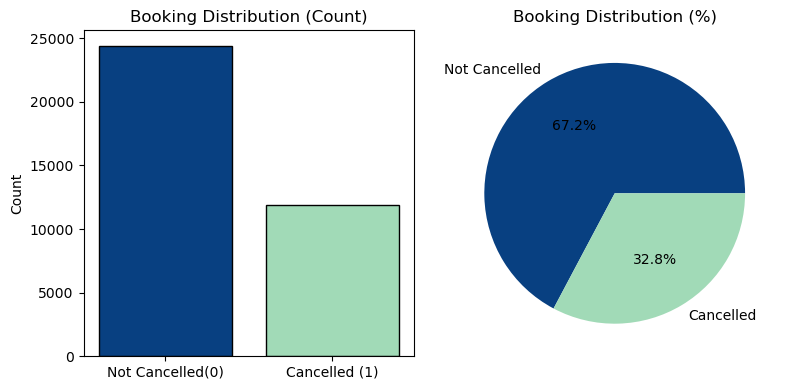

In [668]:
# Count and percentage of booking status
booking_counts = data['booking status'].value_counts()
booking_pct = data['booking status'].value_counts(normalize=True) * 100

print(f"Cancelled (0): {booking_counts[0]:,} ({booking_pct[0]:.1f}%)")
print(f"Not Cancelled(1): {booking_counts[1]:,} ({booking_pct[1]:.1f}%)")

# Visualize

#BAR CHART
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].bar(['Not Cancelled(0)', 'Cancelled (1)'], booking_counts.values, color=['#084081', '#a1dab7'], edgecolor='black')
axes[0].set_title('Booking Distribution (Count)')
axes[0].set_ylabel('Count')

#PIE CHART
axes[1].pie(booking_counts.values, labels=['Not Cancelled', 'Cancelled'], autopct='%1.1f%%', colors=['#084081', '#a1dab7'])
axes[1].set_title('Booking Distribution (%)')

plt.tight_layout()
plt.show()

---
#### Price and Value

##### Q2. What is the financial impact of booking cancellations on Hotel Haven's revenue?

Canceled: 4,297,005.07 (37.86%)
Not_Canceled: 7,054,162.38 (62.14%)


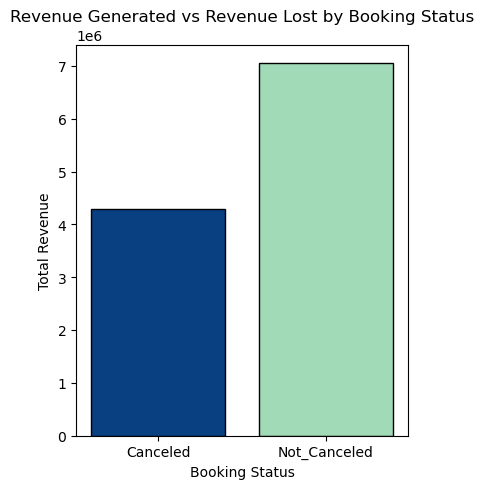

  booking status  total_revenue  percentage
0       Canceled     4297005.07       37.86
1   Not_Canceled     7054162.38       62.14


In [669]:

# Engineering the total nights stayed and and total revenue per booking
data['total_nights'] = data['number of weekend nights'] + data['number of week nights']
data['total_revenue'] = data['average price'] * data['total_nights']

# Total revenue summary by booking status
revenue_summary = data.groupby('booking status')['total_revenue'].sum().reset_index()
revenue_summary.columns = ['booking status', 'total_revenue']

# Compute revenue summary in percentage
total = revenue_summary['total_revenue'].sum()
revenue_summary['percentage'] = (revenue_summary['total_revenue'] / total * 100).round(2)

# Print with percentage in brackets
for _, row in revenue_summary.iterrows():
    print(f"{row['booking status']}: {row['total_revenue']:,.2f} ({row['percentage']}%)")

# Visualization
plt.figure(figsize=(4, 5))
colors = ['#084081', '#a1dab7']

plt.bar(revenue_summary['booking status'], revenue_summary['total_revenue'], color=colors, edgecolor='black')
plt.title('Revenue Generated vs Revenue Lost by Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(revenue_summary)

###### **Insights**:
###### 1. Approximately 4.18 million (37.37%) of total revenue lost to cancellations, representing a major financial threat to the business
###### 2. Only 62.63% of revenue (~7 million) was realized, meaning nearly 4 in every 10 revenue units was lost due to the perishable nature of hotel room inventory

---
##### Q3. Do higher-priced bookings cancel more than lower-priced ones?

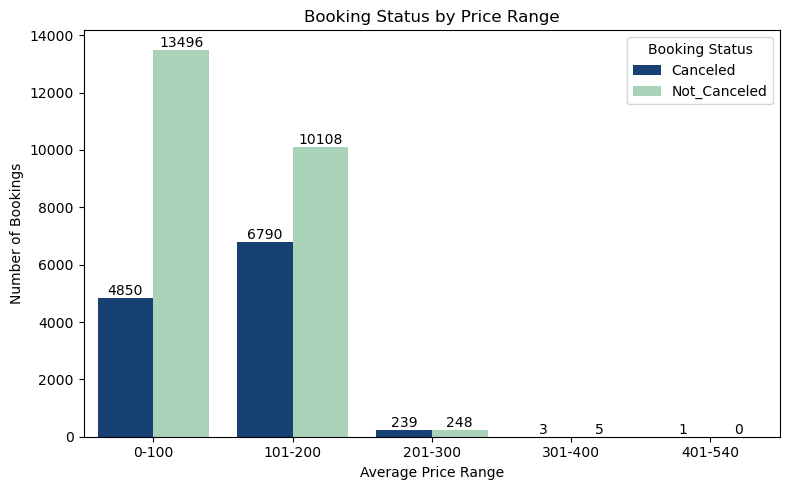

In [670]:
# Bin the average price into ranges
bins = [0, 100, 200, 300, 400, 540]
labels = ['0-100', '101-200', '201-300', '301-400', '401-540']
data['avg_price_range'] = pd.cut(data['average price'], bins=bins, labels=labels)

# Count canceled and not canceled per price range
price_status = data.groupby(['avg_price_range', 'booking status']).size().reset_index(name='count')

# Bar chart - Canceled vs Not Canceled side by side per price range
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=price_status, x='avg_price_range', y='count', hue='booking status', palette=('#084081', '#a1dab7'))

for container in ax.containers: ax.bar_label(container, fmt='%.0f')

plt.title('Booking Status by Price Range')
plt.xlabel('Average Price Range')
plt.ylabel('Number of Bookings')
plt.legend(title='Booking Status')
plt.tight_layout()
plt.show()

##### **Insights**:
##### 1. Cancellations are concentrated in the 0-200 price range
##### 2. The 101-200 price range is Hotel Haven's biggest cancellation problem, with nearly 6,790 cancellations, representing the greatest source of lost revenue for the hotel
##### 3. **Budget to mid-range rooms (0-200) dominate Hotel Haven's bookings**, with the hotel's revenue and cancellation risk both heavily concentrated in this segment
##### 4. **Premium rooms (301-540) contribute negligibly to cancellations**, not because premium guests are more loyal,
##### but because Hotel Haven attracts very few premium bookings in the first place

---
##### Q4. Do expensive bookings made far in advance cancel at a higher rate?

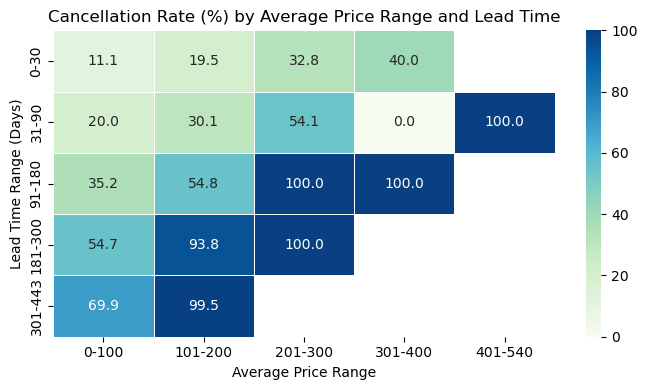

In [671]:
# Bin lead time into ranges
lead_bins = [0, 30, 90, 180, 300, 443]
lead_labels = ['0-30', '31-90', '91-180', '181-300', '301-443']
data['lead_time_range'] = pd.cut(data['lead time'], bins=lead_bins, labels=lead_labels)

# Calculate cancellation rate per price range and lead time range
heatmap_data = data.groupby(['lead_time_range', 'avg_price_range'])['booking status'].apply(lambda x:(x=='Canceled').sum() / len(x) * 100).reset_index()
heatmap_data.columns = ['lead_time_range', 'avg_price_range', 'cancellation_rate']

# Pivot for heatmap
heatmap_pivot = heatmap_data.pivot(index='lead_time_range', columns='avg_price_range', values='cancellation_rate')

# Plot heatmap
plt.figure(figsize=(7, 4))
sns.heatmap(heatmap_pivot, annot=True, fmt='.1f', cmap='GnBu', linewidths=0.5)
plt.title('Cancellation Rate (%) by Average Price Range and Lead Time')
plt.xlabel('Average Price Range')
plt.ylabel('Lead Time Range (Days)')

plt.tight_layout()
plt.show()

In [672]:
filtered_data = data[data['average price'] > 300]
booking_status_counts = filtered_data['booking status'].value_counts()
print(booking_status_counts)

booking status
Not_Canceled    5
Canceled        4
Name: count, dtype: int64


##### *Insights*:
##### 1. **Lead time is the dominant cancellation driver** - the longer a guest books in advance, the more likely they are to cancel, regardless of price
##### 2. **Short lead time bookings are the safest** - bookings made 0-30 days before arrival have the lowest cancellation rates across all price
##### guests who book <=30 days before arrival are far more likely to follow through, making them Hotel Haven's most dependable customer segment for resource planning
##### 3. **Medium-to-high priced rooms booked far in advance are the highest risk bookings** - cancellation rates hit 100% in several of these intersections, representing the greatest source of lost revenue for the hotel
##### 4. **Early planners are budget bookers** - guests who book 300+ days in advance only do so for lower priced rooms (0-$300), not premium ones
##### 5. **Premium bookings (301-540) are made closer to the stay date** - no guest booked a high priced room more than 180 days in advance

---
#### Room Type

##### Q5. Are guests booked into certain room types more likely to follow through with their reservation?

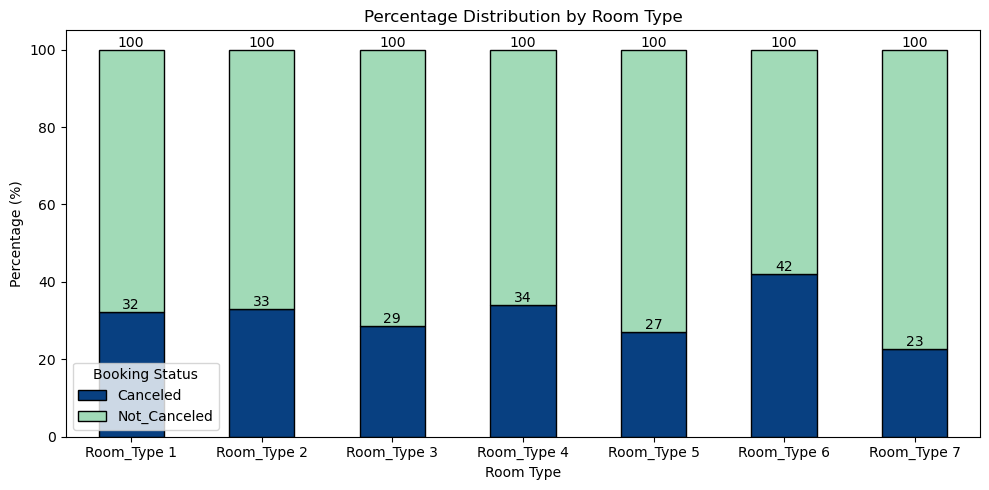

In [673]:
# Calculate proportions of room type
rt_type = pd.crosstab(data['room type'], data['booking status'], normalize='index') * 100

# plot the chart
ax = rt_type.plot(kind='bar', stacked=True, figsize=(10, 5), color=('#084081', '#a1dab7'), edgecolor='black')

for container in ax.containers: ax.bar_label(container, fmt='%.0f')
plt.title('Percentage Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Booking Status')

plt.tight_layout()
plt.show()

##### **Insights**:
##### No clear/consistent pattern of cancellation rates across room types, with slight variations suggesting room type alone is not a strong predictor of cancellation
##### Room Type 6 has highest cancellation rate (42%), slight higher, making it Hotel Haven's most at-risk room inventory, Room Type 7 is the most reliable with the lowest cancellation rate (23%)
##### The absence of descriptive information about each room type limits our ability to explain why certain room types experience higher cancellation rates than others


---
#### Market Segment Type

##### Q6. Does the market segment through which a guest book influence their booking status at Hotel Haven?

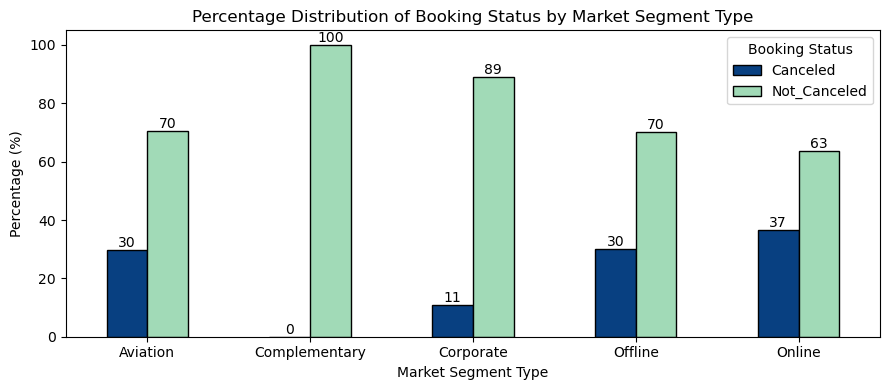

In [674]:
# Calculate proportions of market segment type
market_type = pd.crosstab(data['market segment type'], data['booking status'], normalize='index') * 100

# Group bar chart
ax = market_type.plot(kind='bar', stacked=False, figsize=(9, 4), color=('#084081', '#a1dab7'), edgecolor='black')

for container in ax.containers: ax.bar_label(container, fmt='%.0f')
plt.title('Percentage Distribution of Booking Status by Market Segment Type')
plt.xlabel('Market Segment Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Booking Status')

plt.tight_layout()
plt.show()

##### **Insights**
##### 1. Online bookings have the highest cancellation rate (30%), making them Hotel Haven's biggest cancellation risk. Their seamless booking and cancellation process directly contributes to revenue loss and inefficient resource allocation
##### 2. With only 11% cancellation rate, corporate guests demonstrate strong booking commitment, representing a stable and predictable revenue stream and efficient resource planning segment
##### 3. Complementary bookings have a 0% cancellation rate, strategic bookings provided at no charge to partners, loyalty members, or media, guests have no reason to cancel. While they generate no direct revenue, they can serve as a basis for revenue generation via verbal referrals, and positive reviews for Hotel Haven


##### Q7. Is the number of special requests a reliable signal of a guest's intention to honour their booking?

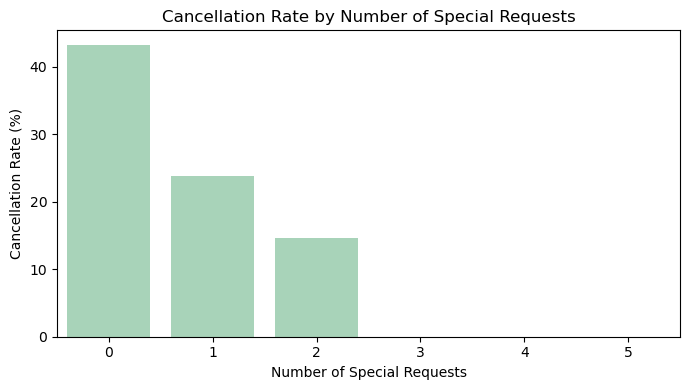

special requests  booking status
0                 Not_Canceled       56.789687
                  Canceled           43.210313
1                 Not_Canceled       76.228140
                  Canceled           23.771860
2                 Not_Canceled       85.403300
                  Canceled           14.596700
3                 Not_Canceled      100.000000
4                 Not_Canceled      100.000000
5                 Not_Canceled      100.000000
Name: proportion, dtype: float64

In [675]:
# Calculate cancellation rate per special request count
special_request_rate = data.groupby('special requests')['booking status'].apply(lambda x: (x == 'Canceled').mean() * 100).reset_index()
special_request_rate.columns = ['special_requests', 'cancellation_rate']

# Bar chart - Cancellation rate by number of special requests
plt.figure(figsize=(7, 4))
ax = sns.barplot(data=special_request_rate, x='special_requests', y='cancellation_rate', color= '#a1dab7')

plt.title('Cancellation Rate by Number of Special Requests')
plt.xlabel('Number of Special Requests')
plt.ylabel('Cancellation Rate (%)')

plt.tight_layout()
plt.show()

data.groupby('special requests')['booking status'].value_counts(normalize=True) * 100

##### **Insights**:
##### 1. Special request is a reliable signal of booking commitment and a strong predictor of whether a guest will honour their reservation, each additional special request made at booking significantly reduces the likelihood of cancellation
##### 2. Guests with 3 or more special requests rarely cancel, representing the most committed and reliable customer segment
##### 3. Guests with zero special requests cancel at 43%, making them Hotel Haven's highest cancellation risk segment

#### f. INVESTIGATE AND HANDLE OUTLIERS

##### Investigate outliers with histogram

In [676]:

numerical_columns = data.select_dtypes(include=['number'])

In [677]:
numerical_columns.head()

,number of adults,number of children,number of weekend nights,number of week nights,lead time,average price,special requests,total_nights,total_revenue
0,1,1,2,5,224,88.00,0,7,616.00
1,1,0,1,3,5,106.68,1,4,426.72
2,2,1,1,3,1,50.00,0,4,200.00
3,1,0,0,2,211,100.00,1,2,200.00
4,1,0,1,2,48,77.00,0,3,231.00


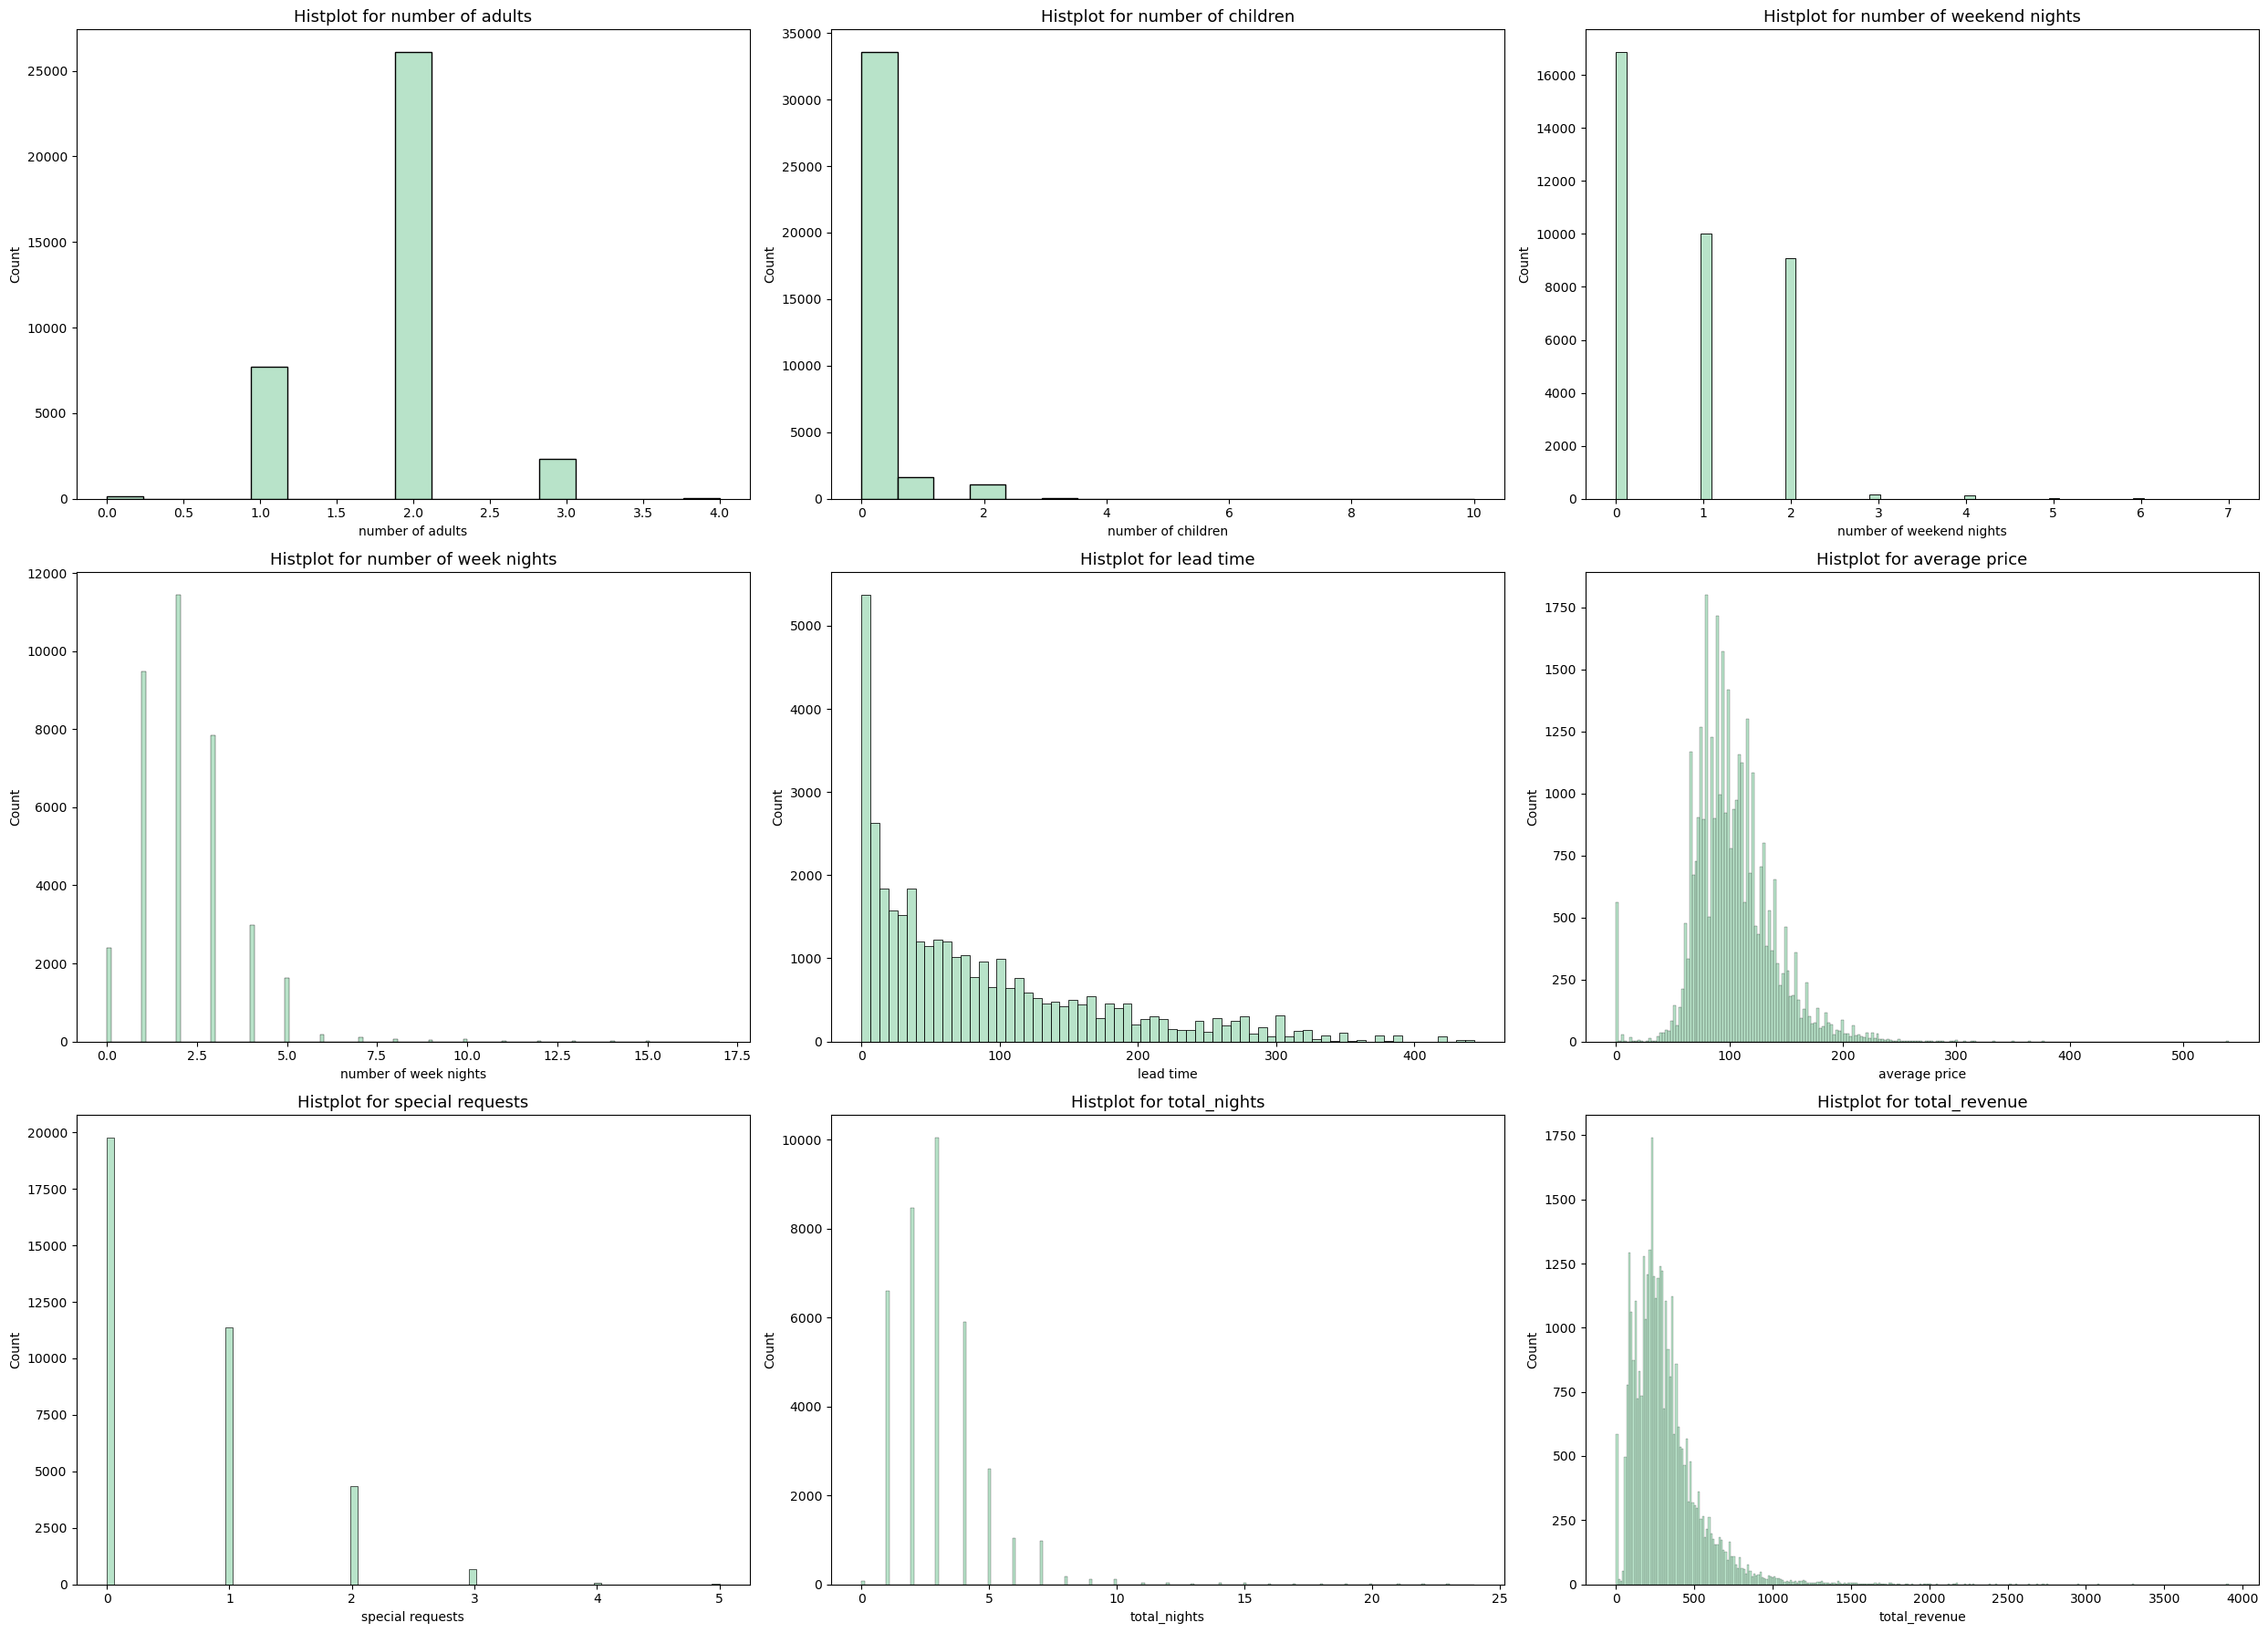

In [678]:
fig, ax = plt.subplots(nrows = 3, ncols = 3, figsize = (25, 18))
ax = ax.flatten()

for idx, col in enumerate (numerical_columns):
    sns.histplot(data[col], ax =ax[idx], color='#a1dab7')
    ax[idx].set_title(f'Histplot for {col}',fontsize=13)

plt.tight_layout()
plt.show()

##### Reconfirm outliers using boxplot

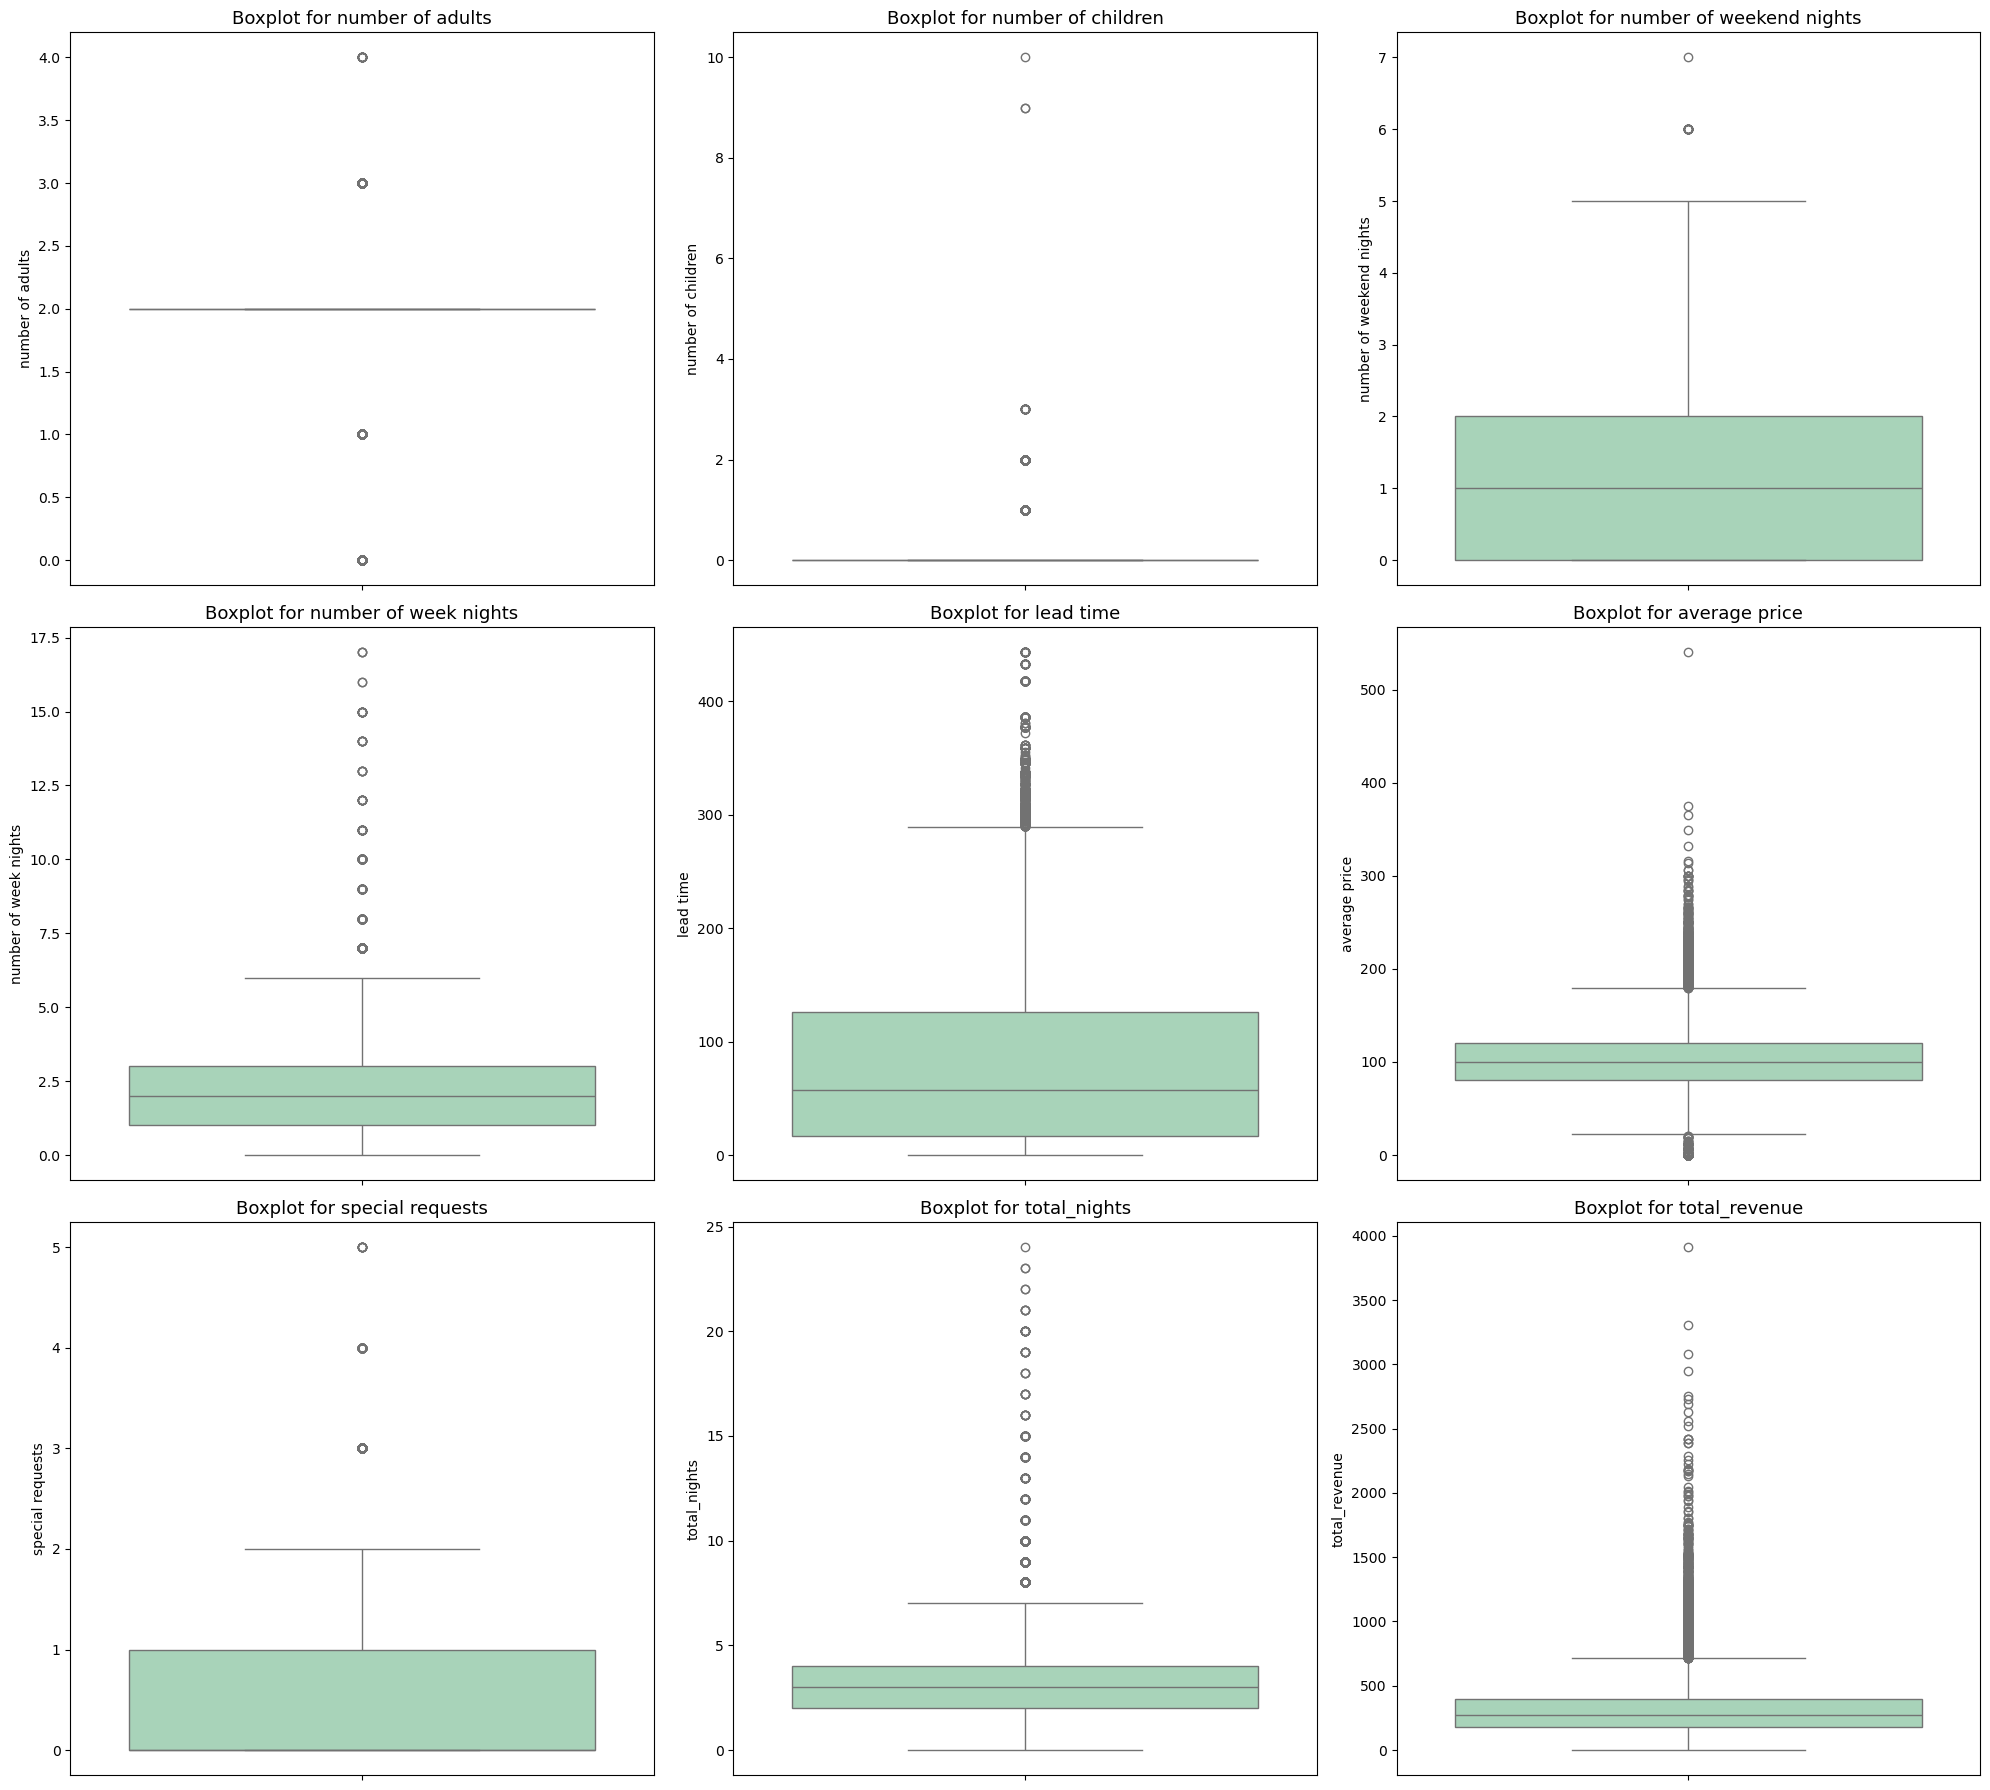

In [679]:

fig, ax = plt.subplots(nrows = 3, ncols = 3, figsize = (20, 18))
ax = ax.flatten()

for idx, col in enumerate (numerical_columns):
    sns.boxplot(data[col], ax =ax[idx], color='#a1dab7')
    ax[idx].set_title(f'Boxplot for {col}', fontsize=13)

plt.tight_layout()
plt.show()

##### Remove outliers from affected columns

In [680]:
affected_columns=['number of weekend nights', 'number of week nights', 'lead time', 'average price', 'special requests', 'total_nights', 'total_revenue']

In [681]:
q1 = data[affected_columns].quantile(0.25)
q3 = data[affected_columns].quantile(0.75)

In [682]:
iqr = q3-q1

In [683]:
lower_bound = q1-(1.5 * iqr)
upper_bound = q3+(1.5 * iqr)

In [684]:
data[affected_columns] = data[affected_columns].clip(lower=lower_bound, upper=upper_bound, axis=1)

##### Verify if data is now free from outlier

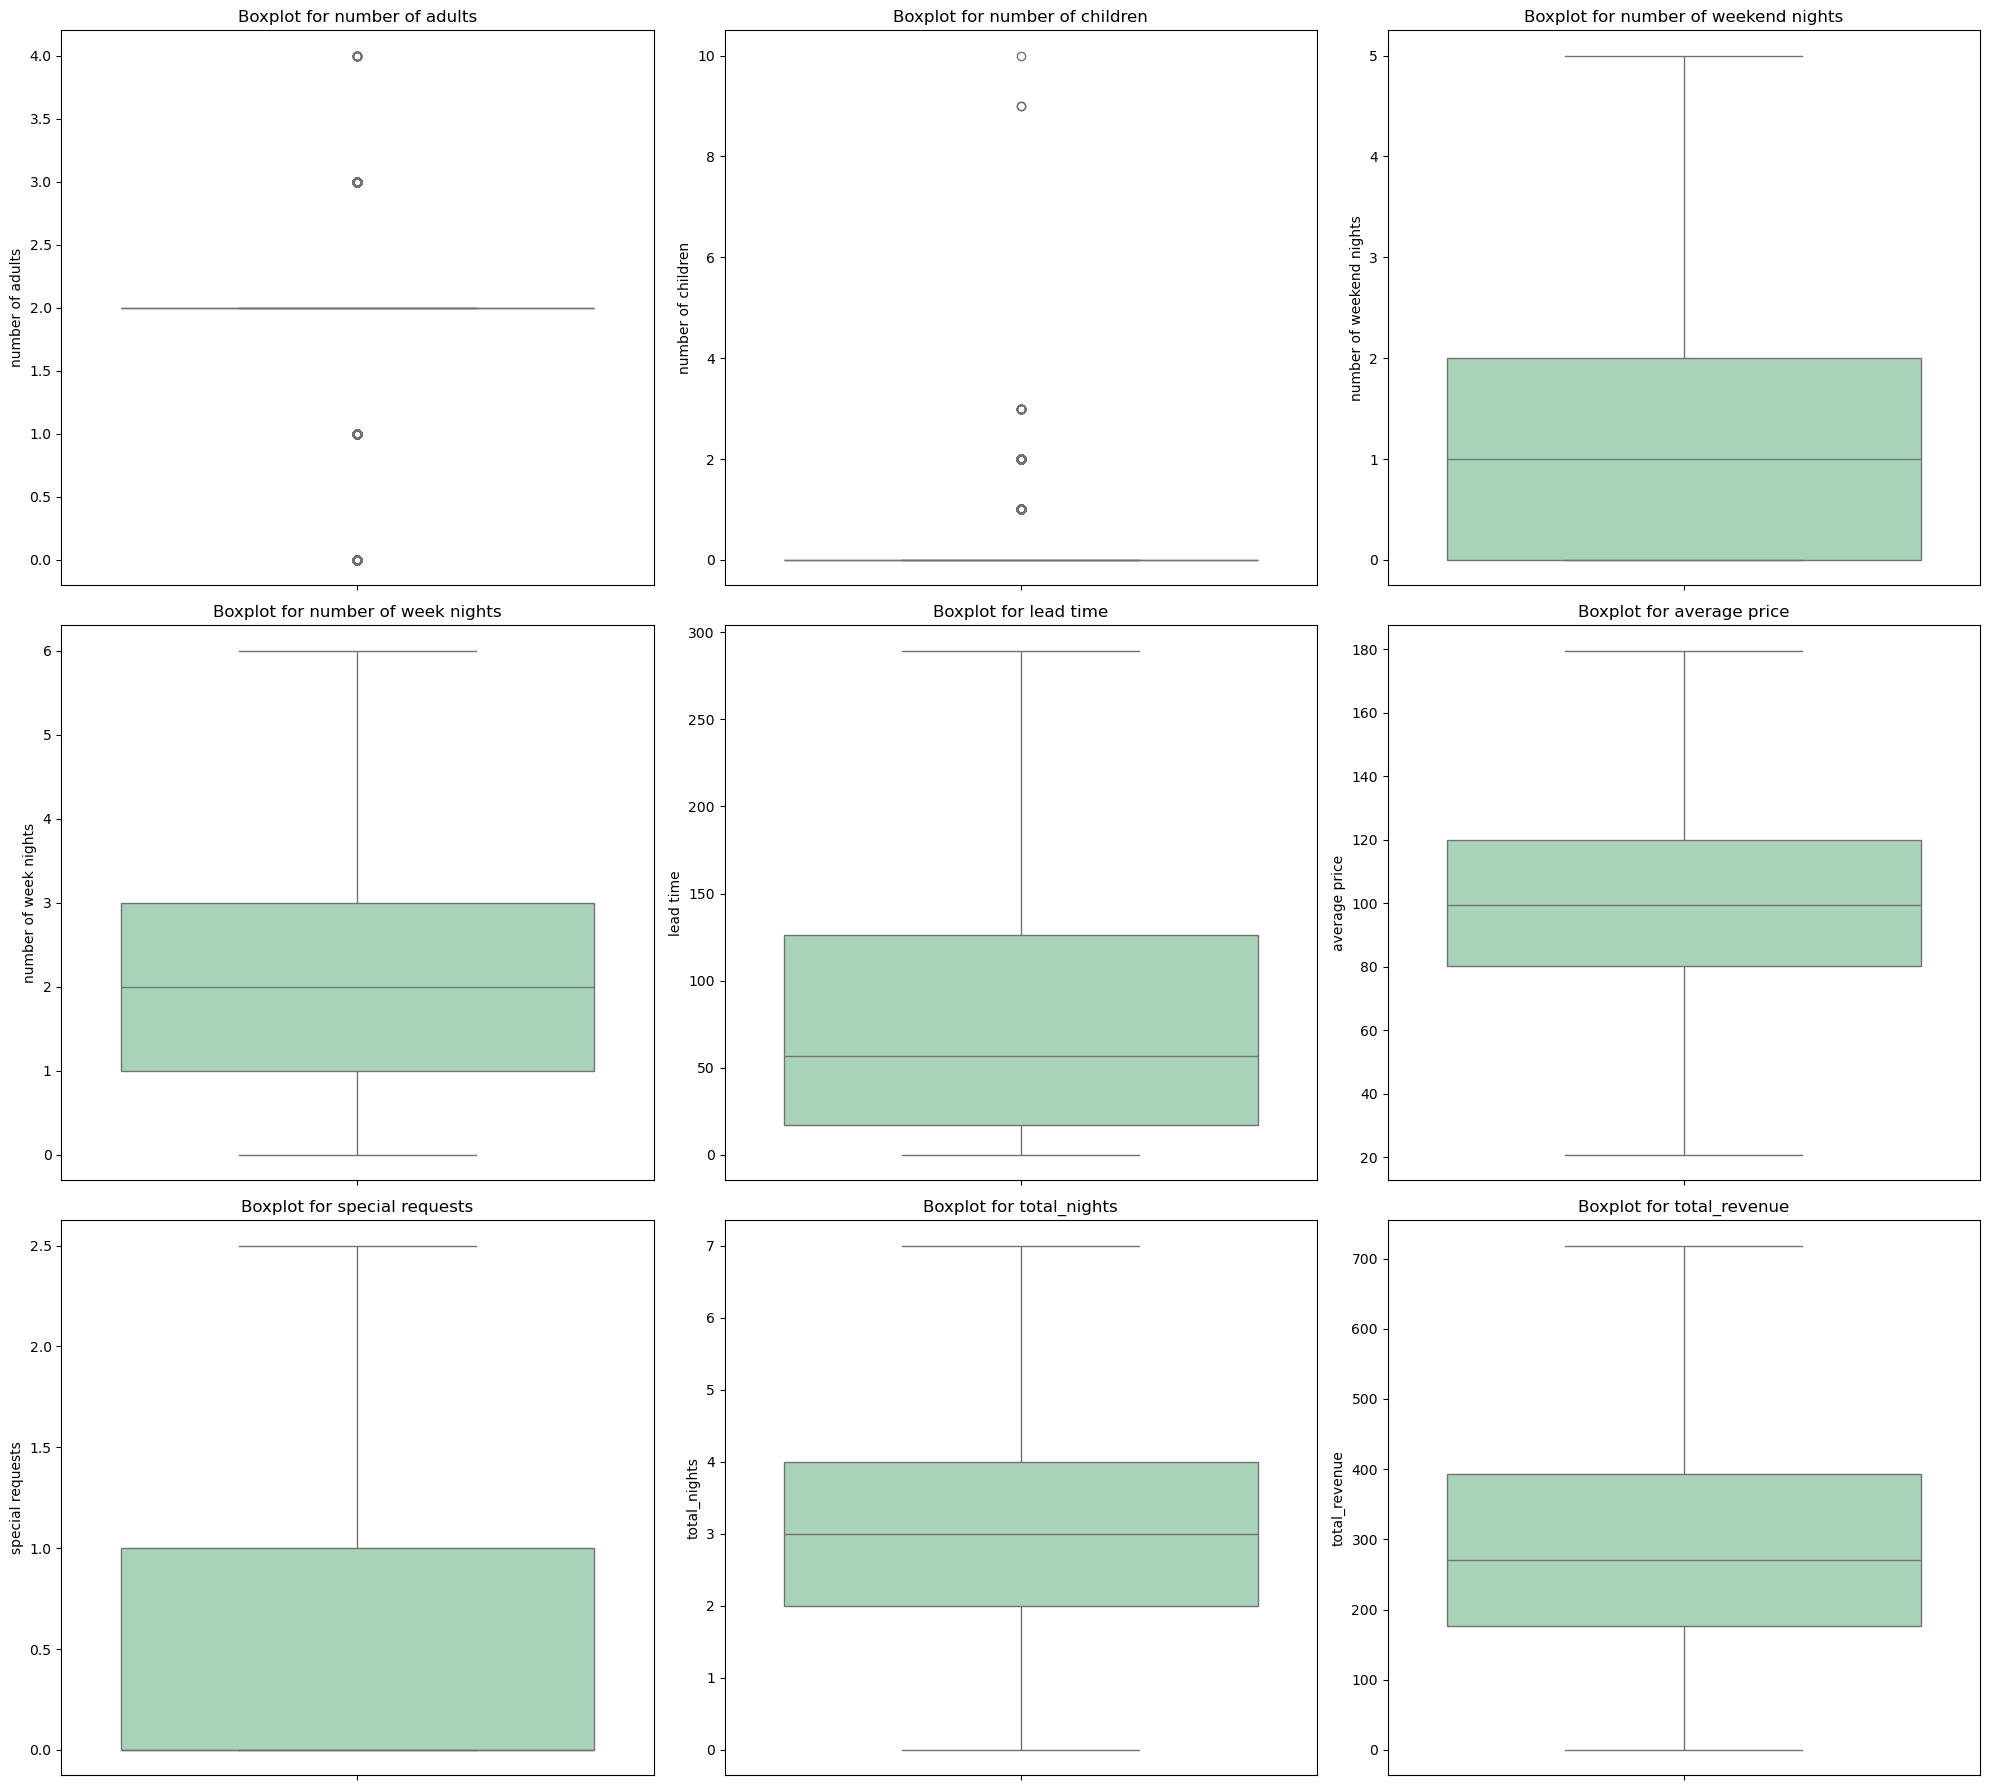

In [685]:
fig, ax = plt.subplots(nrows = 3, ncols = 3, figsize = (20, 18))
ax = ax.flatten()

for idx, col in enumerate (numerical_columns):
    sns.boxplot(data[col], ax =ax[idx], color='#a1dab7')
    ax[idx].set_title(f'Boxplot for {col}')

plt.tight_layout()
plt.show()

#### Drop Features Non-Contributing to Model Training

In [686]:
data.drop(['date_clean', 'avg_price_range', 'lead_time_range'], axis=1, inplace=True)

#### g. Encode Categorical Features

##### Type of meal, car parking space, room type, market segment, repeated and booking status

In [687]:
data.head(2)

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,average price,special requests,booking status,total_nights,total_revenue
0,1,1,2,5,Meal Plan 1,False,Room_Type 1,224.0,Offline,False,88.00,0.0,Not_Canceled,7,616.00
1,1,0,1,3,Not Selected,False,Room_Type 1,5.0,Online,False,106.68,1.0,Not_Canceled,4,426.72


In [688]:
!pip install scikit-learn

In [689]:
# Import library

from sklearn.preprocessing import LabelEncoder

In [690]:
# Initialize the encoder

encoder = LabelEncoder()

In [691]:
data['type of meal'] = encoder.fit_transform(data['type of meal'])
data['car parking space'] = encoder.fit_transform(data['car parking space'])
data['room type'] = encoder.fit_transform(data['room type'])
data['market segment type'] = encoder.fit_transform(data['market segment type'])
data['repeated'] = encoder.fit_transform(data['repeated'])
data['booking status'] = encoder.fit_transform(data['booking status'])

In [692]:
data.head(2)

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,average price,special requests,booking status,total_nights,total_revenue
0,1,1,2,5,0,0,0,224.0,3,0,88.00,0.0,1,7,616.00
1,1,0,1,3,3,0,0,5.0,4,0,106.68,1.0,1,4,426.72


##### Q8.Which booking variables are most strongly associated with a guest's likelihood to cancel or honour their reservation at Hotel Haven?

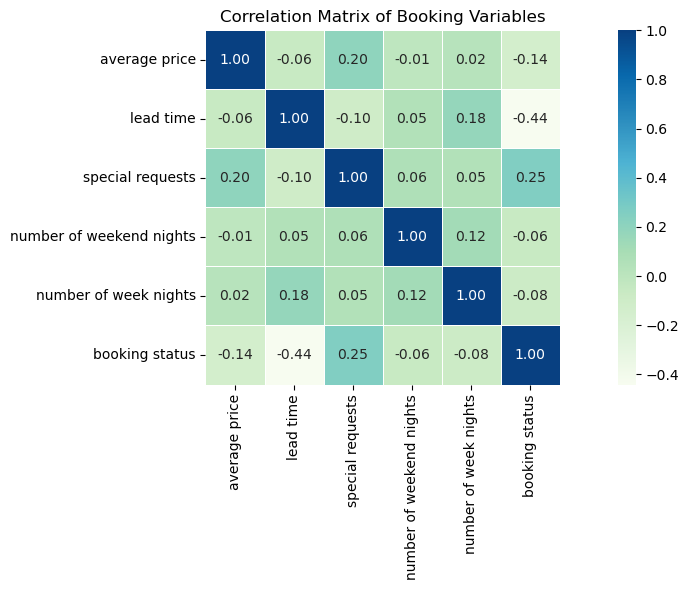

Correlations with Booking Status (sorted):
lead time                  -0.441743
special requests            0.254178
average price              -0.143094
number of week nights      -0.084664
number of weekend nights   -0.060993
Name: booking status, dtype: float64


In [693]:
# Select relevant variables including target
corr_vars = ['average price', 'lead time','special requests', 'number of weekend nights', 'number of week nights',
             'booking status']

# Correlation matrix
corr_matrix = data[corr_vars].corr()



# Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='GnBu', linewidths=0.5, square=True)
plt.title('Correlation Matrix of Booking Variables')
plt.tight_layout()
plt.show()

# Show which features correlate most with the target
print("Correlations with Booking Status (sorted):")
print(corr_matrix['booking status'].drop('booking status').sort_values(key=abs, ascending=False))

##### **Insights**:
##### 1. Lead time and special requests are the two variables most strongly linked to booking status (Lead time is most powerful cancellation predictor)
##### 2. Lead time has the strongest negative correlation with booking status (-0.44). The longer the lead time, the more likely a booking is to be cancelled
##### 3. Special requests have the strongest positive correlation with booking status (0.25) hence, guests who make more special requests are significantly more likely to honour their booking, reinforcing our earlier finding

#### h. Scale Numerical Features

In [694]:
# import library

from sklearn.preprocessing import RobustScaler

In [695]:
# Initialize RobustScaler

scaler = RobustScaler()

In [696]:
# Define numerical variables to scale

num_features_to_scale = ['lead time', 'average price', 'special requests', 'total_revenue']

In [697]:
# Step 3: Scale the numerical variables

data[num_features_to_scale] = scaler.fit_transform(data[num_features_to_scale])

In [698]:
data.head()

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,average price,special requests,booking status,total_nights,total_revenue
0,1,1,2,5,0,0,0,1.532110,3,0,-0.288413,0.0,1,7,1.594470
1,1,0,1,3,3,0,0,-0.477064,4,0,0.182116,1.0,1,4,0.722212
2,2,1,1,3,0,0,0,-0.513761,4,0,-1.245592,0.0,0,4,-0.322581
3,1,0,0,2,0,0,0,1.412844,4,0,0.013854,1.0,0,2,-0.322581
4,1,0,1,2,3,0,0,-0.082569,4,0,-0.565491,0.0,0,3,-0.179724


### i. Check Class Distribution

##### Assess the balance of the target variable (Booking status) if we need to handle class imbalance

In [699]:
data['booking status'].value_counts(normalize=True)*100

booking status
1    67.234394
0    32.765606
Name: proportion, dtype: float64

<Axes: xlabel='booking status', ylabel='count'>

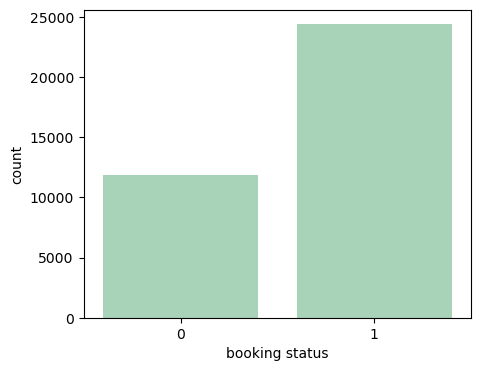

In [700]:
# Visualize distribution

plt.figure(figsize =(5,4))
sns.countplot(x=data['booking status'], color='#a1dab7')

###### **Insight**: A clear case of imbalance in the target variable in which the number of booking not cancelled is two times that cancelled 

##### Handle Imbalance

###### Using Synthetic Minority Oversampling Technique (SMOTE) to handle imbalance

In [701]:
!pip install imbalanced-learn

In [702]:
# import library

from imblearn.over_sampling import SMOTE

###### separate features from target

In [703]:
X =data.drop('booking status', axis=1)
y = data['booking status']

In [704]:
X.head(2)

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,average price,special requests,total_nights,total_revenue
0,1,1,2,5,0,0,0,1.532110,3,0,-0.288413,0.0,7,1.594470
1,1,0,1,3,3,0,0,-0.477064,4,0,0.182116,1.0,4,0.722212


In [705]:
y.head(2)

0    1
1    1
Name: booking status, dtype: int64

In [706]:
# Apply SMOTE, with randomization to make the result re-producible

smote = SMOTE(random_state=42)

# Re-sample data
X_resampled, y_resampled = smote.fit_resample(X,y)

###### Re-validate to check if imbalance is handled

In [707]:
y_resampled.value_counts()

booking status
1    24396
0    24396
Name: count, dtype: int64

In [708]:
y_resampled.value_counts(normalize=True)*100

booking status
1    50.0
0    50.0
Name: proportion, dtype: float64

Imbalance successfully handled


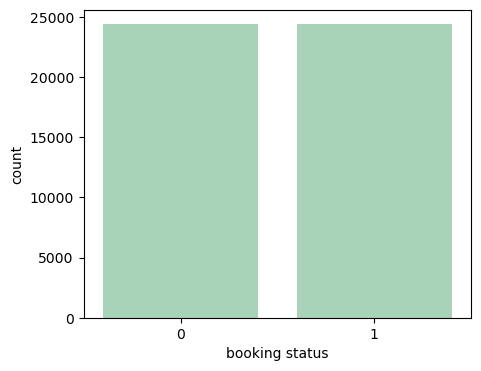

In [709]:
# Visualize Re-distribution

plt.figure(figsize = (5,4))
sns.countplot(x=y_resampled, color='#a1dab7')

print('Imbalance successfully handled')

###### Merge Resampled Features and Target

In [710]:
resampled_data = pd.DataFrame(X_resampled, columns=X.columns)

In [711]:
resampled_data.head(2)

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,average price,special requests,total_nights,total_revenue
0,1,1,2,5,0,0,0,1.532110,3,0,-0.288413,0.0,7,1.594470
1,1,0,1,3,3,0,0,-0.477064,4,0,0.182116,1.0,4,0.722212


In [712]:
resampled_data['booking status'] = y_resampled

In [713]:
resampled_data.head(2)

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,average price,special requests,total_nights,total_revenue,booking status
0,1,1,2,5,0,0,0,1.532110,3,0,-0.288413,0.0,7,1.594470,1
1,1,0,1,3,3,0,0,-0.477064,4,0,0.182116,1.0,4,0.722212,1


---
## Dataset is Cleaned and Ready for Model Training

###### Save Dataset

In [714]:
resampled_data.to_csv('Cleaned_Hotel_Haven_Booking_Status_Balanced.csv', index=False)

## Modelling

### Data Splitting

###### To split the cleaned dataset into training and testing sets such that the target variable (booking status) is distributed in both

In [715]:
# Import library

from sklearn.model_selection import train_test_split

In [716]:
# Split the dataset in 80% for train and 20% for testing

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size = 0.2, random_state = 42)

In [717]:
print(f'Training data size: {len(X_train)}')
print(f'Testing data size: {len(X_test)}')

Training data size: 39033
Testing data size: 9759


In [718]:
# Rechecking if we still have a balanced dataset after splitting (y_train set)
y_train.value_counts(normalize=True)*100

booking status
0    50.11913
1    49.88087
Name: proportion, dtype: float64

In [719]:
y_test.value_counts(normalize=True)*100

booking status
1    50.476483
0    49.523517
Name: proportion, dtype: float64

In [720]:
data.head()

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,average price,special requests,booking status,total_nights,total_revenue
0,1,1,2,5,0,0,0,1.532110,3,0,-0.288413,0.0,1,7,1.594470
1,1,0,1,3,3,0,0,-0.477064,4,0,0.182116,1.0,1,4,0.722212
2,2,1,1,3,0,0,0,-0.513761,4,0,-1.245592,0.0,0,4,-0.322581
3,1,0,0,2,0,0,0,1.412844,4,0,0.013854,1.0,0,2,-0.322581
4,1,0,1,2,3,0,0,-0.082569,4,0,-0.565491,0.0,0,3,-0.179724


### Model Selection

#### 1. Train first with a Baseline Model - Logistic Regression

In [721]:
# Import library

from sklearn.linear_model import LogisticRegression

In [722]:
# Model initialization

model = LogisticRegression(random_state = 42)

In [723]:
# Model training

model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [724]:
# Model testing (Prediction on the test set)

y_prediction = model.predict(X_test)

###### Evaluate Model Performance

In [725]:
# Import library

from sklearn.metrics import classification_report, confusion_matrix

In [726]:
report = classification_report(y_test, y_prediction)
matrix = confusion_matrix(y_test, y_prediction)

In [727]:
# Print report

print('Logistic Regression Classification Report')
print(report)

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.77      0.76      0.77      4833
           1       0.77      0.78      0.77      4926

    accuracy                           0.77      9759
   macro avg       0.77      0.77      0.77      9759
weighted avg       0.77      0.77      0.77      9759



#### 2. Train Advance Model (Random Forest)

In [728]:
from sklearn.ensemble import RandomForestClassifier

In [729]:
# Model initialization
rf_model = RandomForestClassifier(random_state = 42)

# Model training
rf_model.fit(X_train, y_train)

# Model testing (Prediction on the test set)
y_prediction = rf_model.predict(X_test)

# Evaluate Model Performance
report = classification_report(y_test, y_prediction)

# Print report
print('Random Forest Classification Report')
print(report)

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      4833
           1       0.90      0.90      0.90      4926

    accuracy                           0.89      9759
   macro avg       0.89      0.89      0.89      9759
weighted avg       0.89      0.89      0.89      9759



#### 3. Multiple Classification Models

In [730]:
# Import libraries

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [731]:
# Initialize the models

models = {'Logistic Regression' : LogisticRegression(random_state = 42, class_weight = 'balanced'),
          'Random Forest' : RandomForestClassifier(random_state = 42, class_weight = 'balanced'),
          'Gradient Boosting' : GradientBoostingClassifier(random_state = 42),
          'Ada Boost' : AdaBoostClassifier(random_state = 42),
          'SVC' : SVC(random_state = 42, class_weight = 'balanced'),
          'KNeighbors' : KNeighborsClassifier(),
          'Decision Tree' : DecisionTreeClassifier(random_state = 42, class_weight = 'balanced'),
          'XG Boost' : XGBClassifier(eval_metric = 'mlogloss')
         }

Training Logistic Regression...
Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.77      0.76      0.77      4833
           1       0.77      0.78      0.77      4926

    accuracy                           0.77      9759
   macro avg       0.77      0.77      0.77      9759
weighted avg       0.77      0.77      0.77      9759



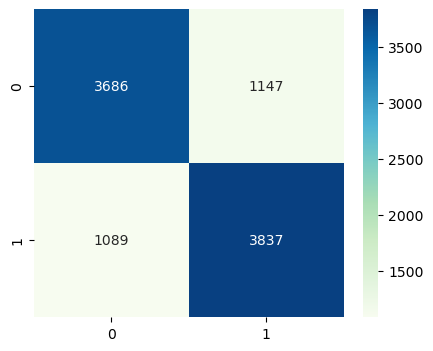

Training Random Forest...
Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      4833
           1       0.89      0.90      0.89      4926

    accuracy                           0.89      9759
   macro avg       0.89      0.89      0.89      9759
weighted avg       0.89      0.89      0.89      9759



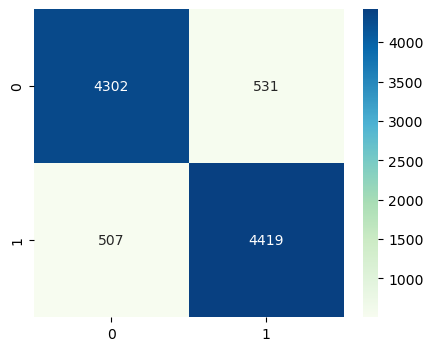

Training Gradient Boosting...
Gradient Boosting Classification Report
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      4833
           1       0.82      0.84      0.83      4926

    accuracy                           0.82      9759
   macro avg       0.82      0.82      0.82      9759
weighted avg       0.82      0.82      0.82      9759



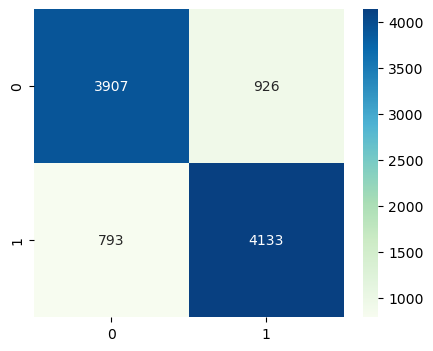

Training Ada Boost...
Ada Boost Classification Report
              precision    recall  f1-score   support

           0       0.77      0.77      0.77      4833
           1       0.77      0.78      0.78      4926

    accuracy                           0.77      9759
   macro avg       0.77      0.77      0.77      9759
weighted avg       0.77      0.77      0.77      9759



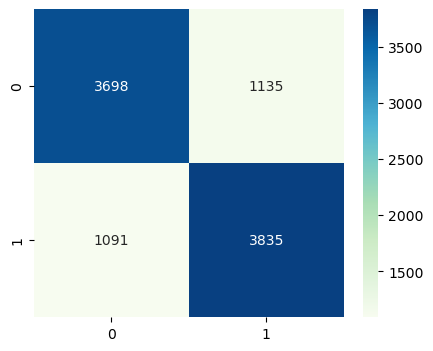

Training SVC...
SVC Classification Report
              precision    recall  f1-score   support

           0       0.78      0.80      0.79      4833
           1       0.80      0.78      0.79      4926

    accuracy                           0.79      9759
   macro avg       0.79      0.79      0.79      9759
weighted avg       0.79      0.79      0.79      9759



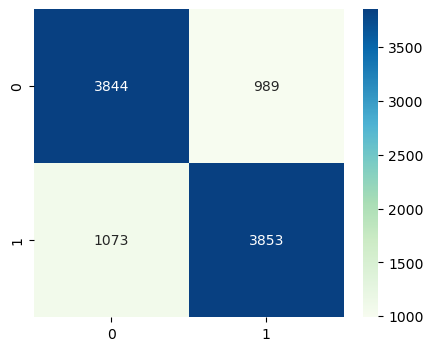

Training KNeighbors...
KNeighbors Classification Report
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      4833
           1       0.88      0.83      0.86      4926

    accuracy                           0.86      9759
   macro avg       0.86      0.86      0.86      9759
weighted avg       0.86      0.86      0.86      9759



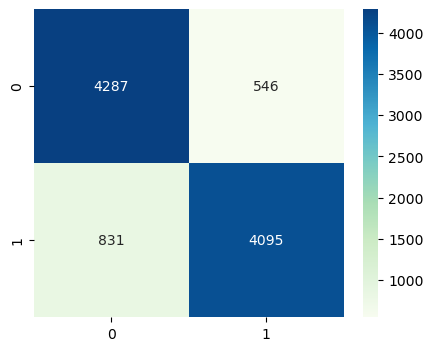

Training Decision Tree...
Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      4833
           1       0.87      0.86      0.86      4926

    accuracy                           0.86      9759
   macro avg       0.86      0.86      0.86      9759
weighted avg       0.86      0.86      0.86      9759



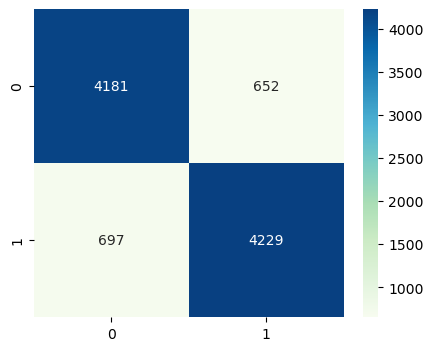

Training XG Boost...
XG Boost Classification Report
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      4833
           1       0.86      0.88      0.87      4926

    accuracy                           0.87      9759
   macro avg       0.87      0.87      0.87      9759
weighted avg       0.87      0.87      0.87      9759



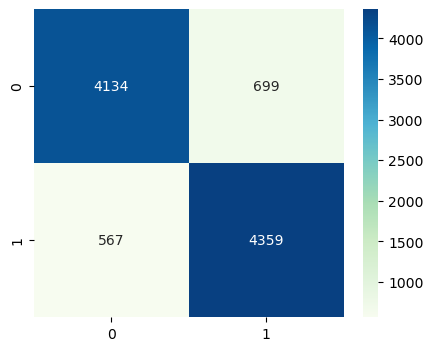

In [732]:
# Import library
from sklearn.metrics import accuracy_score

# Create a dictionary to store all the results from the models
results = {}

for model_name, model in models.items():
    print(f'Training {model_name}...')

    # Model training
    model.fit(X_train, y_train)
    
    # Model testing (Prediction on the test set)
    y_prediction = model.predict(X_test)
    
    # Evaluate the models performance
    accuracy = accuracy_score(y_test, y_prediction)
    report = classification_report(y_test, y_prediction)
    matrix = confusion_matrix(y_test, y_prediction)

    # Store results
    results[model_name] = {
        'accuracy': accuracy,
        'classification_report': report,
        'confusion_matrix': matrix
    }
    # Print report
    print(f'{model_name} Classification Report')
    print(report)

    # Plot confusion matrix
    plt.figure(figsize = (5,4))
    sns.heatmap(matrix, cmap = 'GnBu', annot=True, fmt='g')
    plt.show()

### Random Forest is the best performancing Model

#### 4. Hyperparametric Tuning

###### Using Grid search to optimize the hyperparameters for the Random Forest model

In [733]:
# import library

from sklearn.model_selection import GridSearchCV

In [734]:
# Define the Parameter Grid

parameter_grid = {
    'n_estimators' : [50, 100, 200],
    'max_depth' : [None,10, 20, 30],
    'min_samples_split' : [2, 4, 10,],
    'min_samples_leaf' : [1, 2, 5],
    }

In [735]:
# Model initialization

grid_search = GridSearchCV(RandomForestClassifier(random_state = 42, class_weight = 'balanced'),
                          param_grid = parameter_grid,
                          scoring='f1',
                          cv=5,
                          n_jobs=-1)

In [736]:
# Model Training

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 4, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='f1')

In [737]:
# Query Best Parameters

print(f'Best Hyperparamters: {grid_search.best_params_}')

Best Hyperparamters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 200}


In [738]:
# Train best model

best_rf = grid_search.best_estimator_

In [739]:
# Predict test sets

y_pred_best_rf = best_rf.predict(X_test)

In [740]:
# Model evaluation

print('Fine-tuned Random Forest Classifier')
report = classification_report(y_test, y_pred_best_rf)
print(report)

Fine-tuned Random Forest Classifier
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      4833
           1       0.89      0.90      0.90      4926

    accuracy                           0.90      9759
   macro avg       0.90      0.90      0.90      9759
weighted avg       0.90      0.90      0.90      9759



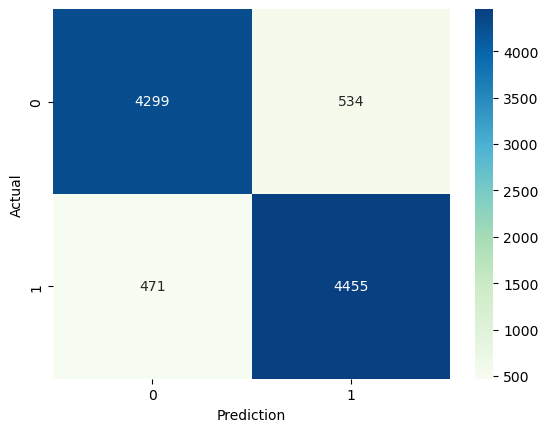

In [741]:
# Model evaluation continues

matrix = confusion_matrix(y_test, y_pred_best_rf)
sns.heatmap(matrix, annot=True,cmap='GnBu', fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

#### ROC Score and AUC Curve

###### To Further evaluation to assess the model's ability to differential class

In [742]:
# Import library

from sklearn.metrics import roc_curve, roc_auc_score

In [743]:
# Compute the probabilities for ROC

y_probs = best_rf.predict_proba(X_test)[:, 1]

In [744]:
# ROC Curve

fpr, tpr, threshold = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

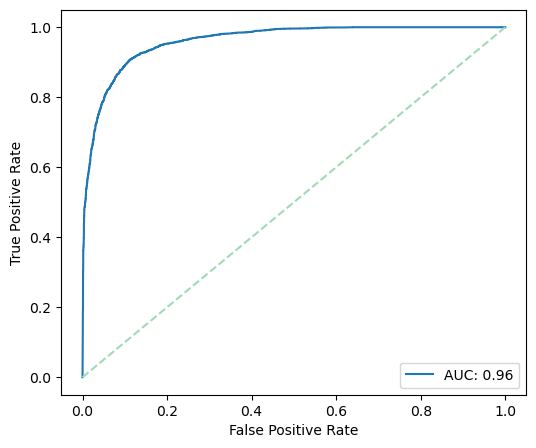

In [745]:
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label = f'AUC: {auc_score:.2f}')
plt.plot([0, 1], [0, 1], linestyle = '--', color = '#a1dab7')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

## Recommendations
* Use deposits, prepaid rates, or credit card to increase booking commitment

* Offer flexible options such as rescheduling or partial refunds instead of full cancellation for lower priced rooms, giving budget guests a financial incentive to commit at the point of booking

* Room upgrades or loyalty reward to guests who book directly (offline market segment)

* Identify long lead-time bookings at an early stage and proactively engage these guests with personalized campaigns, promotional upgrades and experience packages

* Offer small incentives for guests who keep long-lead bookings

* Improve listing accuracy by ensuring room descriptions, photos, amenities, and prices match the actual experience

* Actively grow the corporate segment by proactive contracts negotiation and corporate rate agreements with companies, and travel agencies, as their accommodation partner for corporate travellers

* Incorporate more options in special-request fields